# Week 12 Hands-On: Running an AMBER Simulation of Alanine Dipeptide on Pete

This notebook is a **Pete-adapted** version of the AMBER alanine dipeptide tutorial:

**AMBER tutorial:** *Simple Simulation of Alanine Dipeptide*  
https://ambermd.org/tutorials/basic/tutorial0/index.php

## Goals

By the end of this hands-on lesson, you should be able to:

- create a working directory for Week 12 on Pete
- load the AMBER environment
- build alanine dipeptide with **`tleap`** (not `xleap`)
- generate `parm7` and `rst7` files
- prepare AMBER input files for minimization, heating, and production
- run minimization and MD
- do a small amount of post-processing with `cpptraj`

## Important adaptation for Pete

The original tutorial creates a generic `Tutorial` folder.  
For this course, start in:

`/projects/tia001/$USER/week12`

> Note: your prompt said `/projects/tia001/$SUER`, which appears to be a typo.  
> In the commands below I use the standard environment variable **`$USER`**.

## Set up your Week 12 working directory on Pete

Create a `week12` directory in our shared project space.

```bash
mkdir -p /projects/tia001/$USER/week12
```

Move into that directory

```bash
cd /projects/tia001/$USER/week12
```

Load the amber module so that your shell has access to the amber executables

```bash
module load amber
```

Check that the amber executables are available

```bash
echo $AMBERHOME
which tleap
```

## Build alanine dipeptide with `tleap`

This follows the AMBER tutorial closely:

1. load the `ff14SB` protein force field
2. build alanine dipeptide as `ACE-ALA-NME`
3. load the TIP3P water model
4. solvate in an octahedral box with a 8 Å buffer
5. save `parm7` and `rst7`

We will do this starting `tleap` and then executing a few commands in tleap:

```bash
tleap
```

You should see the following (or comparable) output

```
-I: Adding /opt/amber/18/amber18/dat/leap/prep to search path.
-I: Adding /opt/amber/18/amber18/dat/leap/lib to search path.
-I: Adding /opt/amber/18/amber18/dat/leap/parm to search path.
-I: Adding /opt/amber/18/amber18/dat/leap/cmd to search path.

Welcome to LEaP!
(no leaprc in search path)
```

We start by source the parameters (force constants, charges, etc - called a force field) that we will use for this tutorial

```
> source leaprc.protein.ff14SB
```

You should see the following output:

```
----- Source: /opt/amber/18/amber18/dat/leap/cmd/leaprc.protein.ff14SB
----- Source of /opt/amber/18/amber18/dat/leap/cmd/leaprc.protein.ff14SB done
Log file: ./leap.log
Loading parameters: /opt/amber/18/amber18/dat/leap/parm/parm10.dat
Reading title:
PARM99 + frcmod.ff99SB + frcmod.parmbsc0 + OL3 for RNA
Loading parameters: /opt/amber/18/amber18/dat/leap/parm/frcmod.ff14SB
Reading force field modification type file (frcmod)
Reading title:
ff14SB protein backbone and sidechain parameters
Loading library: /opt/amber/18/amber18/dat/leap/lib/amino12.lib
Loading library: /opt/amber/18/amber18/dat/leap/lib/aminoct12.lib
Loading library: /opt/amber/18/amber18/dat/leap/lib/aminont12.lib
```

Now create a diala object in `tleap` by using the `sequence` command to connect the `ACE` residue to an `ALA` residue to a `NME` residue.

```
> diala = sequence { ACE ALA NME }
```

Now we will add water around our solute.  We start by loading the water parameters

```
> source leaprc.water.tip3p
```

Add a box of TIP3P water around the solute with a buffer of alteast 8 Angstroms on all sides of the solute.
```
> solvatebox diala TIP3PBOX 8.0
```

Save the amber parameter/topology file (parm7) and input coordinates (rst7):
```
> saveamberparm diala diala_solv.parm7 diala_solv.rst7
```

Save a pdb:
```
> savepdb diala diala_solv.pdb
```

Quit tleap:
```
> quit
```

You should now have the following files in your `week12` folder:

```
diala_solv.parm7  diala_solv.pdb  diala_solv.rst7  leap.log
```

You can also achieve this by copying and pasting the following into the terminal directly (from your `week12` folder)

In [ ]:
%%bash
cd /projects/tia001/$USER/week12
ls -lh

## Create AMBER MD input files

We will create three files:

- `min.in` for minimization
- `heat.in` for heating from 0 K to 300 K
- `prod_short.in` for a **short production run suitable for in-class activity**

### `min.in` - Minimization input file

The first stage of performing a molecular dynamics simulation is to make sure your starting structure has a reasonable potential energy.  To achieve this, we need to create a file called `min.in` to specify to amber that we want to do an energy minimization.  Create this file by

```bash
vi min.in
```

then, within vi, enter **input** mode by typing `i`.  Then copy and past the following information into the file (Then save and quit).

```
Minimize
 &cntrl
  imin=1,
  ntx=1,
  irest=0,
  maxcyc=2000,
  ncyc=1000,
  ntpr=100,
  ntwx=0,
  cut=8.0,
 /
```

To save and quit, first hit `esc` to exit input mode, then type `:wq` and hit `enter`/`return`.

If you are unable to get `vi` to work properly, this can all be achieved by copying and pasting the following into a shell command line and then hitting `return`.

```
cat > min.in <<'EOF'
Minimize
 &cntrl
  imin=1,
  ntx=1,
  irest=0,
  maxcyc=2000,
  ncyc=1000,
  ntpr=100,
  ntwx=0,
  cut=8.0,
 /
EOF
```

Make sure you have properly created a file called `min.in` in your `/projects/tia001/$USER/week12` folder.

### `heat.in` - Heating input file

The second stage of a typical MD simulation is to heat the system.  After minimization, the system is basically at 0K, so we need to heat it to the temperature of interest.   We start by creating a `heat.in` file.  This will look similar to the `min.in` file but with important differences.

```bash
vi heat.in
```

Within vi, enter **input** mode by typing `i` then paste the following

```
Heat
 &cntrl
  imin=0,
  ntx=1,
  irest=0,
  nstlim=10000,
  dt=0.002,
  ntf=2,
  ntc=2,
  tempi=0.0,
  temp0=300.0,
  ntpr=100,
  ntwx=100,
  cut=8.0,
  ntb=1,
  ntp=0,
  ntt=3,
  gamma_ln=2.0,
  nmropt=1,
  ig=-1,
 /
&wt type='TEMP0', istep1=0, istep2=9000, value1=0.0, value2=300.0 /
&wt type='TEMP0', istep1=9001, istep2=10000, value1=300.0, value2=300.0 /
&wt type='END'
```

Exit **input** mode by hitting the `esc` key and then typing `:wq` and hitting `return`.

If you cannot get `vi` to work, you can also achieve this by putting this all in a command line and hitting `return`

```
cat > heat.in <<'EOF'
Heat
 &cntrl
  imin=0,
  ntx=1,
  irest=0,
  nstlim=10000,
  dt=0.002,
  ntf=2,
  ntc=2,
  tempi=0.0,
  temp0=300.0,
  ntpr=100,
  ntwx=100,
  cut=8.0,
  ntb=1,
  ntp=0,
  ntt=3,
  gamma_ln=2.0,
  nmropt=1,
  ig=-1,
 /
&wt type='TEMP0', istep1=0, istep2=9000, value1=0.0, value2=300.0 /
&wt type='TEMP0', istep1=9001, istep2=10000, value1=300.0, value2=300.0 /
&wt type='END' /
EOF
```

### `prod.in` - Production run input file

The next phase of MD simulation is the production (or sometimes equilibration) run.  This will generate the data we will analyze.

Again, vi and put in the following:

```bash
vi prod.in
```

```
Production
 &cntrl
  imin=0,
  ntx=5,
  irest=1,
  nstlim=50000,
  dt=0.002,
  ntf=2,
  ntc=2,
  temp0=300.0,
  ntpr=500,
  ntwx=500,
  cut=8.0,
  ntb=2,
  ntp=1,
  ntt=3,
  barostat=1,
  gamma_ln=2.0,
  ig=-1,
 /
```

At `dt = 0.002 ps`, the run length is:

`time (ps) = nstlim × 0.002`

So:

- `nstlim = 50000` gives **100 ps**
- `nstlim = 5000000` gives **10 ns** (tutorial-scale)

## Review the input files

```bash
cd /projects/tia001/$USER/week12

echo "===== 01_Min.in ====="
cat min.in
echo
echo "===== 02_Heat.in ====="
cat heat.in
echo
echo "===== 03_Prod_short.in ====="
cat prod.in
```

## Run minimization

Create the a job submit script called `min.bash` or something similar.  Put the following into the file using `vi` (or `cat` if you need to).

Once you have created `min.bash` with that info, submit the job:

```bash
sbatch min.bash
```

## Inspect the minimization output

You should see the energy decrease during minimization.

## Run heating

Create a submit script for the heating step called `heat.bash`.  This submit script reads `heat.in` and uses the output coordinates from the minimization step (`min.ncrst`).  

Submit the job  using the command

```bash
sbatch heat.bash
```

## Inspect the heating output

Look for temperature increasing during the run.

## 10. Run production MD

Create a job submit script called `prod.bash` that contains the following

submit the job with the command

```bash
sbatch prod.bash
```

## 11. Check the production outputs

## 14. Basic trajectory analysis with `cpptraj`

The original tutorial includes basic post-processing.  
Here we will do two simple analyses:

1. RMSD relative to the first production frame
2. backbone dihedral angles `phi` and `psi` for alanine dipeptide

For alanine dipeptide, `phi`/`psi` are especially useful because they show the conformational sampling of the molecule.

## 15. Plot RMSD and the `phi`/`psi` time series in Python

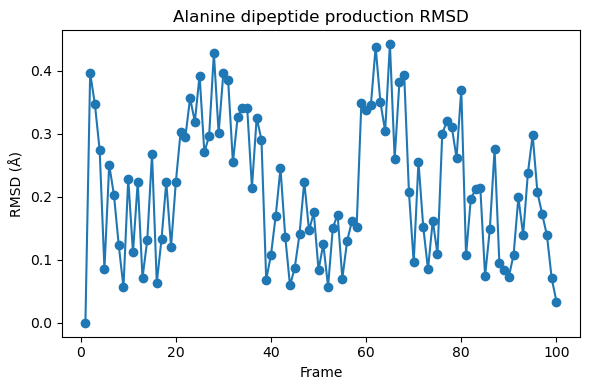

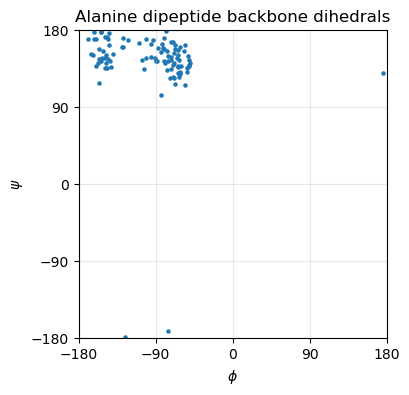

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

work = Path(f"/projects/tia001/{Path.home().name}/week12")

rmsd = np.loadtxt("rmsd.dat", comments="#")
phi = np.loadtxt("phi.dat", comments="#")
psi = np.loadtxt("psi.dat", comments="#")

fig = plt.figure(figsize=(6,4))
plt.plot(rmsd[:,0], rmsd[:,1], '-o')
plt.xlabel("Frame")
plt.ylabel("RMSD (Å)")
plt.title("Alanine dipeptide production RMSD")
plt.tight_layout()
plt.show()

# plot phi psi scatter plot
fig, ax = plt.subplots(figsize=(4,4))

ax.scatter(phi[:,1], psi[:,1], s=5)

ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"$\psi$")
ax.set_title("Alanine dipeptide backbone dihedrals")

# Exact domain
ax.set_xlim(-180, 180)
ax.set_ylim(-180, 180)

# Remove padding
ax.margins(0)
# for tick marks
ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_yticks([-180, -90, 0, 90, 180])
# grid
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=10)
# THIS is the key fix (stronger than set_aspect alone)
ax.set_box_aspect(1)

plt.show()

## Short assignment

Submit answers to the following questions in a word or pdf document to Canvas

1. What files are produced by `tleap`, and what is the role of each?
2. What is the purpose of the minimization stage before heating?
3. Why do we heat gradually instead of starting immediately at 300 K?
4. How would you change `nstlim` to run a 1 ns simulation at `dt = 0.002 ps`?
5. Make a plot of ***RMSD vs trajectory time*** for *your trajectory* and describe what you see.
6. Make a scatter plot of `phi` and `psi`.  Based on the `phi` and `psi` plot, does alanine dipeptide appear to remain in one conformational region or sample multiple regions?